# 1. 项目背景
在日常观看 MLB 比赛时，投手的表现往往通过 ERA、胜负数或少数几项传统数据来评价，但这些指标很难完整反映不同投手在三振、保送、投球稳定性等方面的真实差异。即使在同一个赛季，不同类型投手之间的表现分布也存在明显差别。 本项目选取 Baseball-Reference 提供的 2025 赛季 MLB 投手赛季数据，对投手的基础统计指标进行整理与分析。分析内容主要集中在表面数据层面，包括出场情况、投球局数、三振与保送、ERA / FIP 等常见指标，目的是直观地了解 2025 赛季投手整体表现的分布情况，以及不同投手之间的差异。 本 Notebook 更偏向于数据整理与探索性分析，不涉及复杂建模或逐球层面的研究，重点在于通过简单清晰的统计方法，对当季投手数据形成一个整体认识。

# 2. 数据来源与说明

本项目使用的数据来自 Baseball-Reference，包含 2025 赛季 MLB 投手的常规赛赛季汇总数据。数据以 Excel 格式保存，并在本 Notebook 中进行读取与处理。


In [1]:
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def remove_accents(text):#去除西语名字音调
    if pd.isna(text):
        return text
    text = str(text)
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(c for c in text if not unicodedata.combining(c))
    return text

df = pd.read_excel('pitchers2025regular.xlsx')
df_fwar = pd.read_excel('fangraphWar25.xlsx')
df_fwar = df_fwar.rename(columns={'Name': 'Player'})
df['Player'] = df['Player'].str.replace('*', '', regex=False)#去掉名字后面的*




# 3.数据清洗
需要注意的是，Baseball-Reference 中的投球局数（IP）采用棒球记法，例如 5.1 表示 5 又 1/3 局，5.2 表示 5 又 2/3 局。这种表示方式在表面上是小数，但并不符合标准的十进制数值含义，若直接用于加总或比较，容易产生计算错误。

因此，在后续分析前，先将投球局数统一转换为「出局数（outs）」这一整数形式进行存储。1 局等于 3 个出局数，这样可以避免小数表示带来的歧义。在需要展示或阅读时，再将出局数转换回常见的 IP 记法。

将原始的 IP 字段转换为对应的出局数。K% 定义为三振数占面对打者总数的比例，用于衡量投手的直接压制能力。
检查空值,保证ERA,IP等重要数据里没有空值


In [2]:
def ip_to_outs(IP):
    whole = int(IP)
    frac = round(IP - whole, 1)
    return whole * 3 + int(frac * 10)

def outs_to_ip(outs):
    return outs // 3 + (outs % 3) / 10

df['outs'] = df['IP'].apply(ip_to_outs)
df['K_Percentage'] = (df['SO'] / df['BF'] * 100).round(1)
df['BB_Percentage'] = (df['BB'] / df['BF'] * 100).round(1)


## 将fWar加入进来

In [3]:
df['player_norm'] = df['Player'].apply(remove_accents)
df_fwar['player_norm'] = df_fwar['Player'].apply(remove_accents)


In [4]:
df_fwar_p = df_fwar[df_fwar['IP'] > 0].copy()
df_fwar_p = df_fwar_p[['player_norm', 'Pit WAR']].rename(
    columns={'Pit WAR': 'fWAR'}
)


df = df.merge(
    df_fwar_p, 
    on='player_norm', 
    how='left'
)

# 4.描述统计
 K-BB% = 三振率（K%） − 保送率（BB%）
表示：投手在所有面对打者中，“多制造了多少三振、少给了多少保送”。
将K-BB%作为新的一列,分组区间并非联盟官方定义，而是用于描述性分析，便于比较不同压制能力层级投手的分布情况。

将小于12的定义为tier_1,

12~18的定义为tier_2,

18~22定义为tier_3,

大于22的定义为tier_4


In [5]:
df['K-BB_percentage'] = df['K_Percentage'] - df['BB_Percentage']
bins = [0,12,18,22,30]
labels = ['tier_1', 'tier_2', 'tier_3', 'tier_4']
df['K-BB_tier'] = pd.cut(
    df['K-BB_percentage'],
    bins= bins,
    labels= labels,
    right= False
)

## 筛选出先发投手
将投了140局的投手定义为先发投手

## 筛选出后援投手
将没有先发过,且投过的局数至少为3局的投手定义为后援投手

In [6]:
df_starter = df[df['outs'] >= 140 * 3].copy()

df_bullpen = df[(df['GS'] == 0) & (df['outs'] >= 3 * 3)].copy()

# 5.核心分析
##计算ERA和K-BB%的线性关系
##计算FIP和K-BB%的线性关系

ERA与FIP这两个指标均与K-BB%存在着线性关系,且先发的ERA和K-BB%的线性关系大于牛棚的线性关系,同一类型投手中FIP与K-BB%的线性关系大于ERA和K-BB%的线性关系

特别是先发投手,线性关系较强,但是牛棚只能算是中等相关


In [7]:
df_starter['ERA'].corr(df_starter['K-BB_percentage'])

np.float64(-0.6819514317355315)

In [8]:
df_starter['FIP'].corr(df_starter['K-BB_percentage'])

np.float64(-0.7894725292189281)

In [9]:
df_bullpen['ERA'].corr(df_bullpen['K-BB_percentage'])

np.float64(-0.42871031405946136)

In [10]:
df_bullpen['FIP'].corr(df_bullpen['K-BB_percentage'])

np.float64(-0.5526464661232373)

# 6.可视化
### 将ERA和K-BB%之间对比,画散点图
### 将FIP和K-BB%之间对比,画散点图

<Axes: xlabel='K-BB_percentage', ylabel='ERA'>

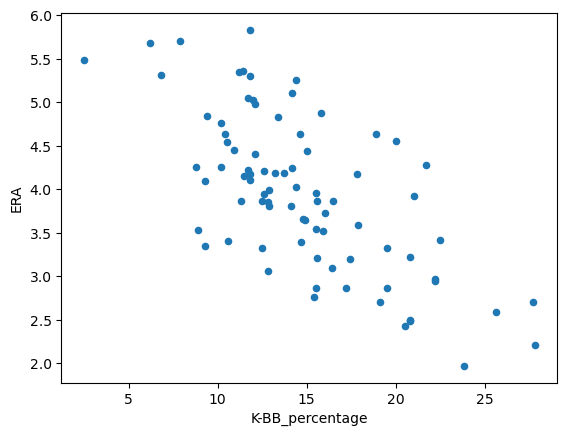

In [11]:
df_starter.plot(x='K-BB_percentage', y='ERA', kind='scatter')

<Axes: xlabel='K-BB_percentage', ylabel='FIP'>

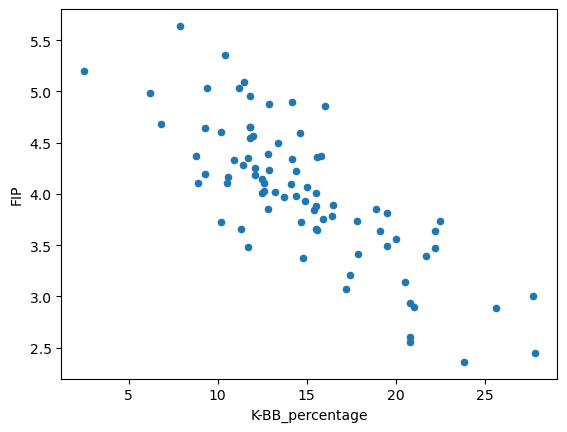

In [12]:
df_starter.plot(x='K-BB_percentage', y='FIP', kind='scatter')

<Axes: xlabel='K-BB_percentage', ylabel='ERA'>

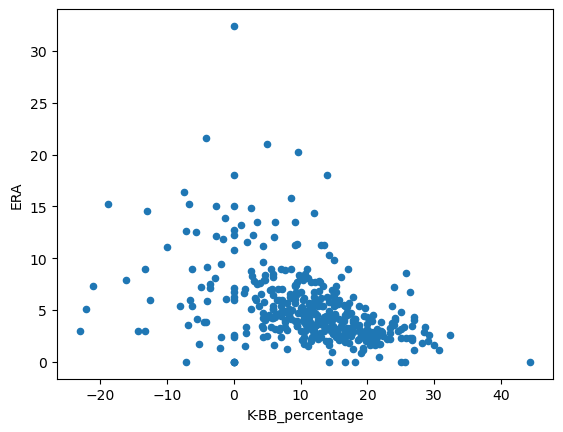

In [13]:
df_bullpen.plot(x='K-BB_percentage', y='ERA', kind='scatter')


<Axes: xlabel='K-BB_percentage', ylabel='FIP'>

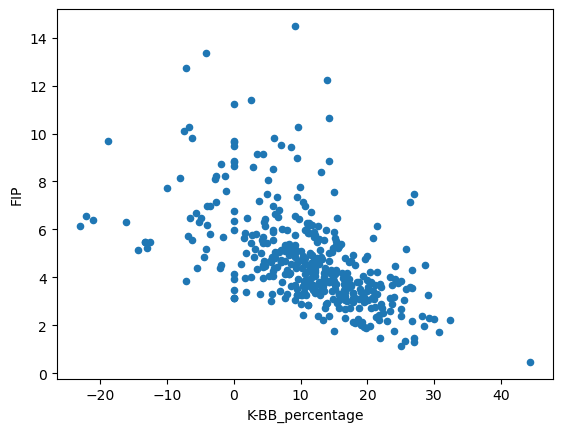

In [14]:
df_bullpen.plot(x='K-BB_percentage', y='FIP', kind='scatter')

ERA与K-BB_percentage的散点图中有一点明显偏离,先发投手中没有像这种程度的偏离
这位是捕手,比分差距过大时上去节约牛棚的,不愧是投手最好的伙伴

本分析基于赛季汇总数据，未区分对手强度、主客场及防守因素，结论仅适用于描述性比较。

In [15]:
df_bullpen[df_bullpen['ERA']>30]

,Rk,Player,Age,Team,Lg,WAR,W,L,W-L%,ERA,...,SO/BB,Awards,Player-additional,outs,K_Percentage,BB_Percentage,player_norm,fWAR,K-BB_percentage,K-BB_tier
768,767,Tyler Heineman,34,TOR,AL,-0.4,0,0,NaN,32.4,...,NaN,NaN,heinety01,10,0.0,0.0,Tyler Heineman,-0.1,0.0,tier_1


# 7.根据K-BB%预测 FIP

In [16]:
df['role'] = 0
df.loc[df['outs'] >= 140*3, 'role'] = 1
df[['FIP', 'K-BB_percentage', 'outs', 'role']].corr()


,FIP,K-BB_percentage,outs,role
FIP,1.000000,-0.529573,-0.263815,-0.098662
K-BB_percentage,-0.529573,1.000000,0.355867,0.137054
outs,-0.263815,0.355867,1.000000,0.768982
role,-0.098662,0.137054,0.768982,1.000000


In [17]:
from sklearn.linear_model import LinearRegression

x = df_starter[['K-BB_percentage']]
y = df_starter['FIP']

model = LinearRegression()
model.fit(x, y)#等价于在拟合这个模型：FIP=β0​+β1​×(K-BB%)
#β1=model.coef_[0]
# β0=model.intercept_



model.coef_, model.intercept_
#model.coef_是一个数组,这个模型里只有 1 个值,表示 K-BB% 每增加 1 个百分点，FIP 平均变化多少

df_starter['FIP_pred'] = model.predict(x)
#使用刚刚训练好的线性回归模型,对每个投手的 K-BB% 代入公式

df_starter['residual'] = df_starter['FIP'] - df_starter['FIP_pred']
#残差 = 真实值 - 预测值,
# 正残差：真实 FIP 比模型预测高 → 投手被低估,
# 负残差：真实 FIP 比模型预测低 → 投手表现超出预期
df_starter


,Rk,Player,Age,Team,Lg,WAR,W,L,W-L%,ERA,...,Player-additional,outs,K_Percentage,BB_Percentage,player_norm,fWAR,K-BB_percentage,K-BB_tier,FIP_pred,residual
0,1,Logan Webb,28,SFG,NL,3.8,15,11,0.577,3.22,...,webblo01,621,26.2,5.4,Logan Webb,5.5,20.8,tier_3,3.336783,-0.736783
1,2,Garrett Crochet,26,BOS,AL,6.3,18,5,0.783,2.59,...,crochga01,616,31.3,5.7,Garrett Crochet,5.8,25.6,tier_4,2.799444,0.090556
2,3,Cristopher Sánchez,28,PHI,NL,8.0,13,5,0.722,2.50,...,sanchcr01,606,26.3,5.5,Cristopher Sanchez,6.4,20.8,tier_3,3.336783,-0.786783
3,4,Max Fried,31,NYY,AL,4.4,19,5,0.792,2.86,...,friedma01,586,23.6,6.4,Max Fried,4.8,17.2,tier_2,3.739787,-0.669787
4,5,Carlos Rodón,32,NYY,AL,4.6,18,9,0.667,3.09,...,rodonca01,586,25.7,9.3,Carlos Rodon,3.2,16.4,tier_2,3.829343,-0.049343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,78,Davis Martin,28,CHW,AL,1.5,7,10,0.412,4.10,...,martida03,428,17.3,8.0,Davis Martin,1.3,9.3,tier_1,4.624157,0.015843
78,79,Taj Bradley,24,2TM,AL,-0.6,6,8,0.429,5.05,...,bradlta01,428,21.0,9.3,Taj Bradley,1.8,11.7,tier_1,4.355488,-0.005488
79,80,Charlie Morton,41,3TM,2LG,-0.8,9,11,0.450,5.83,...,mortoch02,426,22.8,11.0,Charlie Morton,0.3,11.8,tier_1,4.344293,0.615707
80,81,Michael Lorenzen,33,KCR,AL,0.4,7,11,0.389,4.64,...,lorenmi01,425,21.0,6.4,Michael Lorenzen,1.2,14.6,tier_2,4.030845,0.559155


Text(0.5, 1.0, 'FIP vs K-BB% with Regression Line')

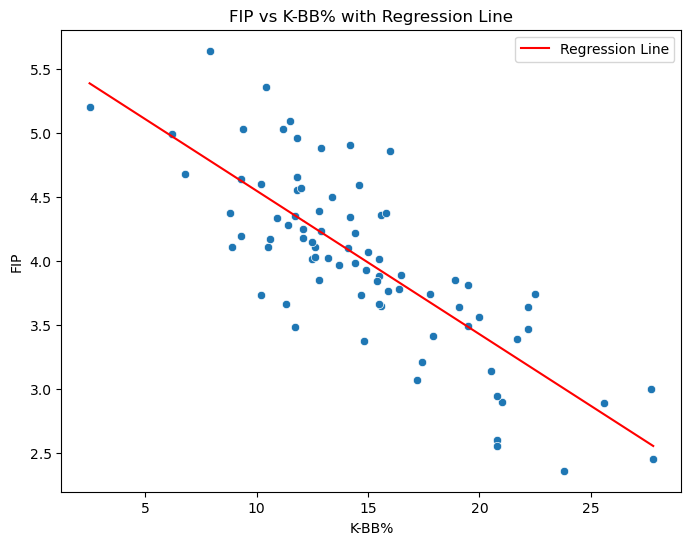

In [18]:
plt.figure(figsize=(8,6))#新建一张画布（Figure）,宽 8 英寸，高 6 英寸
sns.scatterplot(
    x='K-BB_percentage', 
    y='FIP', 
    data=df_starter)
#含义：使用 seaborn 的 scatterplot
# x='K-BB_percentage'
# → 横轴用 DataFrame 中的 K-BB_percentage
# y='FIP'
# → 纵轴用真实的 FIP
# data=df_starter
# → 每一行是一个投手


# 回归线
sns.lineplot(
    x=df_starter['K-BB_percentage'],#用真实的 K-BB% 作为横坐标
    y=df_starter['FIP_pred'],#用你事先算好的预测值
    color='red',#红色线，强调“模型”
    label='Regression Line'
)


plt.xlabel('K-BB%')
plt.ylabel('FIP')
plt.title('FIP vs K-BB% with Regression Line')

In [19]:
# 绝对值最大的 3 个残差
top3 = df_starter.loc[df_starter['residual'].abs().nlargest(3).index]

top3[['Player', 'FIP', 'FIP_pred', 'residual', 'outs', 'ERA']]


,Player,FIP,FIP_pred,residual,outs,ERA
76,Shota Imanaga,4.86,3.874122,0.985878,434,3.73
36,David Peterson,3.48,4.355488,-0.875488,506,4.22
20,Jake Irvin,5.64,4.780881,0.859119,540,5.70


# 8.tWAR

## tFIP

In [20]:
#df_starter.loc[:, ["outs", "FIP"]]
df_starter


,Rk,Player,Age,Team,Lg,WAR,W,L,W-L%,ERA,...,Player-additional,outs,K_Percentage,BB_Percentage,player_norm,fWAR,K-BB_percentage,K-BB_tier,FIP_pred,residual
0,1,Logan Webb,28,SFG,NL,3.8,15,11,0.577,3.22,...,webblo01,621,26.2,5.4,Logan Webb,5.5,20.8,tier_3,3.336783,-0.736783
1,2,Garrett Crochet,26,BOS,AL,6.3,18,5,0.783,2.59,...,crochga01,616,31.3,5.7,Garrett Crochet,5.8,25.6,tier_4,2.799444,0.090556
2,3,Cristopher Sánchez,28,PHI,NL,8.0,13,5,0.722,2.50,...,sanchcr01,606,26.3,5.5,Cristopher Sanchez,6.4,20.8,tier_3,3.336783,-0.786783
3,4,Max Fried,31,NYY,AL,4.4,19,5,0.792,2.86,...,friedma01,586,23.6,6.4,Max Fried,4.8,17.2,tier_2,3.739787,-0.669787
4,5,Carlos Rodón,32,NYY,AL,4.6,18,9,0.667,3.09,...,rodonca01,586,25.7,9.3,Carlos Rodon,3.2,16.4,tier_2,3.829343,-0.049343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,78,Davis Martin,28,CHW,AL,1.5,7,10,0.412,4.10,...,martida03,428,17.3,8.0,Davis Martin,1.3,9.3,tier_1,4.624157,0.015843
78,79,Taj Bradley,24,2TM,AL,-0.6,6,8,0.429,5.05,...,bradlta01,428,21.0,9.3,Taj Bradley,1.8,11.7,tier_1,4.355488,-0.005488
79,80,Charlie Morton,41,3TM,2LG,-0.8,9,11,0.450,5.83,...,mortoch02,426,22.8,11.0,Charlie Morton,0.3,11.8,tier_1,4.344293,0.615707
80,81,Michael Lorenzen,33,KCR,AL,0.4,7,11,0.389,4.64,...,lorenmi01,425,21.0,6.4,Michael Lorenzen,1.2,14.6,tier_2,4.030845,0.559155


In [21]:
df_starter['tFIP'] = ((df_starter['HR']*13 + (df_starter['BB']+df_starter['HBP'])*3 - df_starter['SO']*2) / (df_starter['outs']/3)) + 3.14
# 计算每个先发投手的 FIP（这里用 tFIP 表示临时 FIP）
# FIP = (13*HR + 3*(BB+HBP) - 2*SO) / IP + 常数
# 注意：这里用 outs/3 转换为局数，常数设为 3.14
df_starter['tFIP'] = df_starter['tFIP'].round(2)
df_starter['lgFIP'] = (
    (df['HR'].sum()*13 
    + (df['BB'].sum()+df['HBP'].sum())*3 
    - df['SO'].sum()*2
    )/df['outs'].sum()*3
    )+ 3.14
# 计算联盟 FIP（lgFIP）
# 用联盟所有投手的总 HR、BB、HBP、SO 和总 outs/3（总局数）算出联盟平均 FIP
# 3.14 是 FIP 常数
df_starter['lgFIP'] = df_starter['lgFIP'].round(2)

df_starter['repFIP'] = df_starter['lgFIP']+1.2
# 计算替补投手水平 FIP（Replacement FIP）
# 通常设定比联盟平均高 1.2，表示替补投手水平

df_starter['RAR'] = (df_starter['repFIP'] - df_starter['FIP'])*(df_starter['outs']/3)/9
# 计算投手 RAR（Runs Above Replacement）
# RAR = (替补 FIP - 投手 FIP) * 投球局数 / 9
df_starter['tWAR'] = df_starter['RAR']/9.7
# 计算投手 WAR（tWAR） = RAR / 每胜所需跑数（这里用 9.7）
df_starter['tWAR'] = df_starter['tWAR'].round(2)

df_starter['WAR_dif'] = df_starter['tWAR']-df_starter['fWAR']
# 计算 tWAR 与原 fWAR 的差值

FIP                0.999975
RAR                0.984677
tWAR               0.984673
fWAR               0.966702
HR9                0.805810
SO                 0.796978
FIP_pred           0.790085
K-BB_percentage    0.790085
K_Percentage       0.772348
WAR                0.770664
ERA+               0.767803
ERA                0.761568
SO9                0.722965
HR                 0.677411
SO/BB              0.642741
WHIP               0.615663
residual           0.612958
ER                 0.599853
R                  0.581833
H9                 0.574683
outs               0.564488
IP                 0.563372
Rk                 0.534629
W                  0.519525
W-L%               0.502030
L                  0.361505
BF                 0.359272
IBB                0.292871
BB9                0.289052
GS                 0.274975
CG                 0.260997
BB_Percentage      0.226198
SHO                0.202734
GF                 0.176310
Age                0.174415
H                  0

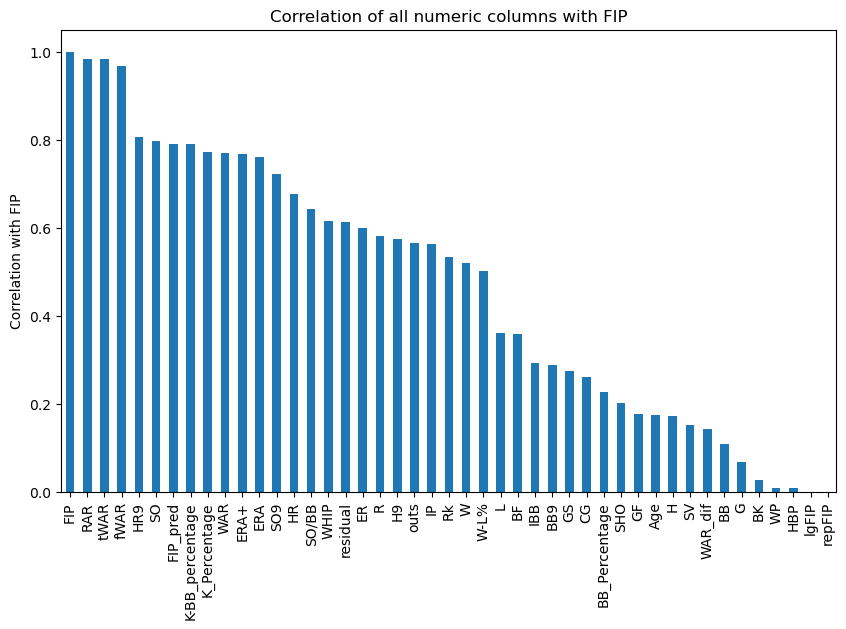

In [22]:
#df_starter.plot(x='', y='WAR_dif', kind='scatter')

df_numeric = df_starter.select_dtypes(include='number')
target_col = 'tFIP'  # 目标列

# 1. 计算所有列与目标列的 Pearson 相关系数
corrs = df_numeric.corr()[target_col]


# 2. 去掉自己（目标列本身的相关系数是 1）
corrs = corrs.drop(target_col)

# 3. 找绝对值最大
strongest_col = corrs.abs().idxmax()
strongest_value = corrs[strongest_col]

corrs_sorted = corrs.abs().sort_values(ascending=False)
print(corrs_sorted)

print(f"与 {target_col} 线性关系最强的列是 {strongest_col}，相关系数为 {strongest_value:.3f}")

import matplotlib.pyplot as plt
corrs_sorted.plot(kind='bar', figsize=(10,6))
plt.ylabel('Correlation with FIP')
plt.title('Correlation of all numeric columns with FIP')
plt.show()



# 9.tWAR_ERA

In [23]:
df_starter['lgERA'] = df_starter['ER'].sum()/(df_starter['outs'].sum()/3)*9
df_starter['lgERA'] = df_starter['lgERA'].round(2)
df_starter['repERA'] = df_starter['lgERA']+1.2

df_starter['RAR_ERA'] = (df_starter['repERA'] - df_starter['ERA'])*(df_starter['outs']/3)/9


df_starter['tWAR_ERA'] = df_starter['RAR_ERA']/9.7

df_starter['tWAR_ERA'] = df_starter['tWAR_ERA'].round(2)

df_starter.sort_values(by='tWAR_ERA').tail(20)


,Rk,Player,Age,Team,Lg,WAR,W,L,W-L%,ERA,...,tFIP,lgFIP,repFIP,RAR,tWAR,WAR_dif,lgERA,repERA,RAR_ERA,tWAR_ERA
6,7,Kevin Gausman,34,TOR,AL,3.8,10,11,0.476,3.59,...,3.42,4.16,5.36,41.816667,4.31,0.21,3.92,5.12,32.810000,3.38
57,58,Ranger Suárez,29,PHI,NL,4.7,12,8,0.600,3.20,...,3.22,4.16,5.36,37.585185,3.87,-0.13,3.92,5.12,33.564444,3.46
21,22,Matthew Boyd,34,CHC,NL,2.5,14,8,0.636,3.21,...,3.65,4.16,5.36,34.136667,3.52,0.12,3.92,5.12,38.129259,3.93
39,40,Gavin Williams,25,CLE,AL,3.8,12,5,0.706,3.06,...,4.40,4.16,5.36,18.070741,1.86,0.46,3.92,5.12,38.377037,3.96
69,70,Drew Rasmussen,29,TBR,AL,4.4,10,5,0.667,2.76,...,3.85,4.16,5.36,25.333333,2.61,0.11,3.92,5.12,39.333333,4.05
70,71,Zack Wheeler,35,PHI,NL,5.0,10,5,0.667,2.71,...,3.01,4.16,5.36,39.245926,4.05,0.05,3.92,5.12,40.077407,4.13
28,29,Jacob deGrom,37,TEX,AL,2.9,12,8,0.600,2.97,...,3.65,4.16,5.36,32.998519,3.40,0.00,3.92,5.12,41.248148,4.25
41,42,Andrew Abbott,26,CIN,NL,5.6,10,7,0.588,2.87,...,3.66,4.16,5.36,31.418519,3.24,-0.66,3.92,5.12,41.583333,4.29
0,1,Logan Webb,28,SFG,NL,3.8,15,11,0.577,3.22,...,2.61,4.16,5.36,63.480000,6.54,1.04,3.92,5.12,43.700000,4.51
4,5,Carlos Rodón,32,NYY,AL,4.6,18,9,0.667,3.09,...,3.79,4.16,5.36,34.291852,3.54,0.34,3.92,5.12,44.058519,4.54


# 10.WAR_dif

In [24]:
df_starter['WAR_dif']

0     1.04
1     0.01
2     0.10
3     0.32
4     0.34
      ... 
77   -0.12
78   -0.15
79    0.35
80    0.05
81    0.46
Name: WAR_dif, Length: 82, dtype: float64

In [25]:
df


,Rk,Player,Age,Team,Lg,WAR,W,L,W-L%,ERA,...,Awards,Player-additional,outs,K_Percentage,BB_Percentage,player_norm,fWAR,K-BB_percentage,K-BB_tier,role
0,1,Logan Webb,28,SFG,NL,3.8,15,11,0.577,3.22,...,ASCYA-4GG,webblo01,621,26.2,5.4,Logan Webb,5.5,20.8,tier_3,1
1,2,Garrett Crochet,26,BOS,AL,6.3,18,5,0.783,2.59,...,ASCYA-2MVP-8,crochga01,616,31.3,5.7,Garrett Crochet,5.8,25.6,tier_4,1
2,3,Cristopher Sánchez,28,PHI,NL,8.0,13,5,0.722,2.50,...,CYA-2MVP-15,sanchcr01,606,26.3,5.5,Cristopher Sanchez,6.4,20.8,tier_3,1
3,4,Max Fried,31,NYY,AL,4.4,19,5,0.792,2.86,...,ASCYA-4GG,friedma01,586,23.6,6.4,Max Fried,4.8,17.2,tier_2,1
4,5,Carlos Rodón,32,NYY,AL,4.6,18,9,0.667,3.09,...,ASCYA-6,rodonca01,586,25.7,9.3,Carlos Rodon,3.2,16.4,tier_2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,869,Luis Torrens,29,NYM,NL,-0.2,0,0,NaN,54.00,...,NaN,torrelu01,2,0.0,12.5,Luis Torrens,-0.1,-12.5,NaN,0
871,870,Carlos Durán,23,ATH,AL,-0.2,0,0,NaN,81.00,...,NaN,duranca01,1,0.0,60.0,Carlos Duran,0.0,-60.0,NaN,0
872,871,Nicky Lopez,30,LAA,AL,0.0,0,0,NaN,0.00,...,NaN,lopezni01,1,0.0,50.0,Nicky Lopez,0.0,-50.0,NaN,0
873,872,Zach McKinstry,30,DET,AL,0.0,0,0,NaN,0.00,...,ASSS,mckinza01,1,0.0,0.0,Zach McKinstry,0.0,0.0,tier_1,0
